# HW2 — Part 1: Training Quantized Models

**Run this notebook on Lambda inside a GPU Slurm session.**  
See `README.md` sections 1.4–1.7 for setup.

In this notebook you will:
1. Train the provided **W16A8** model (16-bit weights, 8-bit activations) and export to ONNX
2. Train the provided **W2A1** model (2-bit weights, 1-bit activations) and export to ONNX
3. Answer the questions after each model
4. Generate test data for the FPGA board
5. (Open-ended) Design, train, and export your own quantization configuration

When done, exit the GPU session and open **`02_synthesis.ipynb`** in a CPU Slurm session (see `README.md` section 1.8).

## 0. Environment Check

In [1]:
import torch
assert torch.cuda.is_available(), "No GPU — start a GPU Slurm session first (see README.md 1.4)"
print(f"GPU:      {torch.cuda.get_device_name(0)}")
print(f"PyTorch:  {torch.__version__}")
import brevitas; print(f"Brevitas: {brevitas.__version__}")

GPU:      NVIDIA GeForce GTX 1080 Ti
PyTorch:  2.5.1+cu121
Brevitas: 0.12.1


In [2]:
import os, sys
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt

import brevitas.nn as qnn
from brevitas.export import export_qonnx
from brevitas.quant.binary import SignedBinaryActPerTensorConst
from brevitas.quant import Int8ActPerTensorFloat

WORKDIR = os.path.expanduser('~/fpga_hw2')
os.makedirs(WORKDIR, exist_ok=True)
os.chdir(WORKDIR)
print(f"Working directory: {WORKDIR}")

INPUT_SIZE  = 3 * 32 * 32  # 3072
HIDDEN_SIZE = 64
NUM_CLASSES = 10
BATCH_SIZE  = 128
DEVICE      = torch.device('cuda')

/home/shahlaandrew/miniforge3/envs/fpga_hw2/lib/python3.10/site-packages/brevitas/graph/equalize.py:69: UserWarning: fast_hadamard_transform package not found, using standard pytorch kernels
  warnings.warn("fast_hadamard_transform package not found, using standard pytorch kernels")


Working directory: /home/shahlaandrew/fpga_hw2


## 1. Data Loading

In [3]:
from torch.utils.data import DataLoader, random_split

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
])
full_train_ds = torchvision.datasets.CIFAR10(root='./data', train=True,  download=True, transform=transform)
test_ds       = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

train_ds, val_ds = random_split(full_train_ds, [45000, 5000],
                                generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=256,        shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=256,        shuffle=False, num_workers=4, pin_memory=True)
print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

Files already downloaded and verified
Files already downloaded and verified
Train: 45000 | Val: 5000 | Test: 10000


/home/shahlaandrew/miniforge3/envs/fpga_hw2/lib/python3.10/site-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


## 2. Training Utilities (provided)

In [4]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct = 0.0, 0
    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        out = model(images)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * labels.size(0)
        correct    += out.argmax(1).eq(labels).sum().item()
    n = len(loader.dataset)
    return total_loss / n, correct / n

def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct = 0.0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            out = model(images)
            total_loss += criterion(out, labels).item() * labels.size(0)
            correct    += out.argmax(1).eq(labels).sum().item()
    n = len(loader.dataset)
    return total_loss / n, correct / n

def train_model(model, epochs, lr, ckpt_path):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    history = {'train_acc': [], 'val_acc': []}
    best_acc = 0.0
    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion)
        vl_loss, vl_acc = evaluate(model, val_loader, criterion)
        scheduler.step()
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(vl_acc)
        print(f'Epoch {epoch:3d}/{epochs}  train={tr_acc:.3f}  val={vl_acc:.3f}')
        if vl_acc > best_acc:
            best_acc = vl_acc
            torch.save(model.state_dict(), ckpt_path)
    print(f'\nBest val accuracy: {best_acc:.3f}  saved to {ckpt_path}')
    return history

def plot_training(history, title):
    epochs = range(1, len(history['train_acc']) + 1)
    plt.figure(figsize=(7, 4))
    plt.plot(epochs, [a*100 for a in history['train_acc']], label='Train')
    plt.plot(epochs, [a*100 for a in history['val_acc']],   label='Val')
    plt.xlabel('Epoch'); plt.ylabel('Accuracy (%)'); plt.title(title)
    plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

print('Utilities ready.')

Utilities ready.


## 3. ONNX Export Utility (provided)

**What is ONNX?** ONNX (Open Neural Network Exchange) is an open format for representing machine learning models as a computation graph. When you call `export_qonnx()`, the trained Brevitas model is serialized into a `.onnx` file that captures every operation — quantized linear layers, activation quantizers, BipolarQuant nodes — along with the learned weights and scale factors. This `.onnx` file is the sole input to FINN in `02_synthesis.ipynb`; FINN reads the graph and compiles each layer into dedicated FPGA hardware.

FINN requires `BipolarQuant` scale == exactly 1.0. This cell exports the model and validates that constraint.

In [5]:
import onnx
import numpy as np

def export_and_validate(model, onnx_path, check_bipolar_scale=True):
    model.eval().cpu()
    dummy = torch.randn(1, INPUT_SIZE)
    export_qonnx(model, input_t=dummy, export_path=onnx_path)

    m = onnx.load(onnx_path)
    bipolar_scale_names = {n.input[1] for n in m.graph.node if n.op_type == 'BipolarQuant'}

    for init in m.graph.initializer:
        if init.name not in bipolar_scale_names:
            continue
        val = float(np.frombuffer(init.raw_data, dtype=np.float32)[0]) if init.raw_data else float(init.float_data[0])
        if check_bipolar_scale and abs(val - 1.0) > 1e-4:
            raise RuntimeError(
                f'BipolarQuant scale = {val:.4f}, expected exactly 1.0. '
                'Use SignedBinaryActPerTensorConst, not QuantHardTanh.')
        # Patch to exactly 1.0 (FINN hard requirement)
        init.raw_data = np.ones(1, dtype=np.float32).tobytes()
        init.float_data[:] = []

    onnx.save(m, onnx_path)
    model.to(DEVICE)
    n_bipolar = len(bipolar_scale_names)
    print(f'Exported: {onnx_path}')
    if n_bipolar:
        print(f'  BipolarQuant scale == 1.0 confirmed ({n_bipolar} node(s))')
    else:
        print('  No BipolarQuant nodes (INT8 model)')

print('Export utility ready.')

Export utility ready.


---
## 4. Model A — W16A8 (16-bit weights, 8-bit activations)

### Background

W16A8 increases weight precision to 16 bits while keeping activations at 8 bits:
- **Weights**: 16-bit integers — stored in FPGA BRAM (expect high BRAM utilization)
- **Activations**: 8-bit integers — FINN compiles to MultiThreshold layers

FINN can synthesize W16A8 because activations stay ≤ 8 bits (FINN's hard limit for MultiThreshold). A pure W16A16 model fails synthesis.

In [ ]:
class QuantFCNetW16A8(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.input_q = qnn.QuantIdentity(act_quant=Int8ActPerTensorFloat, return_quant_tensor=True)
        self.fc1  = qnn.QuantLinear(INPUT_SIZE,  HIDDEN_SIZE, bias=False, weight_bit_width=16, return_quant_tensor=True)
        self.act1 = qnn.QuantIdentity(act_quant=Int8ActPerTensorFloat, return_quant_tensor=True)
        self.fc2  = qnn.QuantLinear(HIDDEN_SIZE, HIDDEN_SIZE, bias=False, weight_bit_width=16, return_quant_tensor=True)
        self.act2 = qnn.QuantIdentity(act_quant=Int8ActPerTensorFloat, return_quant_tensor=True)
        self.fc3  = qnn.QuantLinear(HIDDEN_SIZE, NUM_CLASSES, bias=False, weight_bit_width=16, return_quant_tensor=False)

    def forward(self, x):
        x = self.flatten(x)
        x = self.input_q(x)
        x = self.act1(self.fc1(x))
        x = self.act2(self.fc2(x))
        return self.fc3(x)

model_w16a8 = QuantFCNetW16A8().to(DEVICE)
with torch.no_grad():
    out = model_w16a8(torch.randn(4, INPUT_SIZE, device=DEVICE))
print(f'W16A8 output shape: {out.shape}  (expected [4, 10])')

In [ ]:
history_w16a8 = train_model(model_w16a8, epochs=15, lr=1e-3, ckpt_path='finn_model_w16a8.pt')
plot_training(history_w16a8, 'W16A8 Training Curve')

In [ ]:
model_w16a8.load_state_dict(torch.load('finn_model_w16a8.pt', map_location=DEVICE, weights_only=True))
export_and_validate(model_w16a8, 'model_w16a8.onnx', check_bipolar_scale=False)

### Questions — W16A8
1. What is Quantization-Aware Training (QAT)? How does the gradient flow through the non-differentiable quantization step during backpropagation?
2. Your W16A8 model uses INT8 activations trained with QAT. A float32 MLP of this architecture on CIFAR-10 typically achieves 55–58% test accuracy. How does your result compare, and what does this tell you about the accuracy cost of INT8 quantization with QAT?

**Your answer:**

1.

2.

---
## 5. Model B — W2A1 (2-bit weights, 1-bit activations)

### Background

W2A1 is an extremely aggressive quantization:
- **Weights**: ternary `{-1, 0, +1}` stored as 2-bit values
- **Activations**: bipolar `{-1, +1}` — 1 bit per activation

FINN compiles bipolar activations using XNOR+popcount logic in LUTs — no multipliers needed, very low resource usage.

> **Use `SignedBinaryActPerTensorConst`** for all activation quantizers. It has `scaling_impl_type=CONST` which keeps the scale fixed at 1.0 throughout training. Do **not** use `QuantHardTanh` — its scale is learnable and will drift, causing FPGA threshold miscalibration.

In [ ]:
class QuantFCNetW2A1(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.input_q = qnn.QuantIdentity(act_quant=SignedBinaryActPerTensorConst, return_quant_tensor=True)
        self.fc1  = qnn.QuantLinear(INPUT_SIZE,  HIDDEN_SIZE, bias=False, weight_bit_width=2, return_quant_tensor=True)
        self.act1 = qnn.QuantIdentity(act_quant=SignedBinaryActPerTensorConst, return_quant_tensor=True)
        self.fc2  = qnn.QuantLinear(HIDDEN_SIZE, HIDDEN_SIZE, bias=False, weight_bit_width=2, return_quant_tensor=True)
        self.act2 = qnn.QuantIdentity(act_quant=SignedBinaryActPerTensorConst, return_quant_tensor=True)
        self.fc3  = qnn.QuantLinear(HIDDEN_SIZE, NUM_CLASSES, bias=False, weight_bit_width=2, return_quant_tensor=False)

    def forward(self, x):
        x = self.flatten(x)
        x = self.input_q(x)
        x = self.act1(self.fc1(x))
        x = self.act2(self.fc2(x))
        return self.fc3(x)

model_w2a1 = QuantFCNetW2A1().to(DEVICE)
with torch.no_grad():
    out = model_w2a1(torch.randn(4, INPUT_SIZE, device=DEVICE))
print(f'W2A1 output shape: {out.shape}  (expected [4, 10])')

In [ ]:
history_w2a1 = train_model(model_w2a1, epochs=15, lr=1e-3, ckpt_path='finn_model_w2a1.pt')
plot_training(history_w2a1, 'W2A1 Training Curve')

In [ ]:
model_w2a1.load_state_dict(torch.load('finn_model_w2a1.pt', map_location=DEVICE, weights_only=True))
export_and_validate(model_w2a1, 'model_w2a1.onnx', check_bipolar_scale=True)

In [ ]:
# Confirm ONNX files are ready
for fname in ['model_w2a1.onnx', 'model_w16a8.onnx']:
    path = os.path.join(WORKDIR, fname)
    assert os.path.exists(path), f'Missing {path}'
    print(f'{fname}: {os.path.getsize(path)//1024} KB  ready')
print('\nAll good — exit the GPU session and open 02_synthesis.ipynb')

In [ ]:
# Summary — paste these into 03_board_inference.ipynb when plotting results
# Models already hold best-val checkpoint weights (loaded above for ONNX export)
criterion = nn.CrossEntropyLoss()
_, sw_acc_w2a1_frac  = evaluate(model_w2a1,  test_loader, criterion)
_, sw_acc_w16a8_frac = evaluate(model_w16a8, test_loader, criterion)
sw_acc_w2a1  = sw_acc_w2a1_frac  * 100
sw_acc_w16a8 = sw_acc_w16a8_frac * 100

print('=' * 54)
print('Paste these into 03_board_inference.ipynb cell-19:')
print('=' * 54)
print(f'sw_acc_w2a1  = {sw_acc_w2a1:.1f}')
print(f'sw_acc_w16a8 = {sw_acc_w16a8:.1f}')

---
## 6. Prepare Test Data for the Board

CIFAR-10 test data is already loaded. Generate the board-ready files here while the ONNX models are fresh. Copy commands are in `02_synthesis.ipynb` section 4.

In [ ]:
# Collect all test images from test_loader (already downloaded in section 1)
all_imgs, all_labels = [], []
for imgs_batch, lbls_batch in test_loader:
    all_imgs.append(imgs_batch.numpy())
    all_labels.append(lbls_batch.numpy())
imgs_flat  = np.concatenate(all_imgs).reshape(-1, 3072)   # (10000, 3072), CHW float32
test_lbls  = np.concatenate(all_labels)                    # (10000,)

# W2A1: natural sign → bipolar, FINN packing (bit=0 → +1, bit=1 → -1)
bipolar = np.sign(imgs_flat).astype(np.float32)
bipolar[bipolar == 0] = 1.0
N = len(bipolar)
folded  = bipolar.reshape(N, 768, 4)
binary  = ((1 - folded.astype(np.int8)) // 2).astype(np.uint8)
packed_w2a1 = (binary * np.array([1, 2, 4, 8], dtype=np.uint8)).sum(axis=-1, keepdims=True).astype(np.uint8)

# W16A8: INT8 quantized using the learned input scale from the exported ONNX
m_w16a8 = onnx.load(os.path.join(WORKDIR, 'model_w16a8.onnx'))
quant_scales = {}
for node in m_w16a8.graph.node:
    if node.op_type == 'Quant' and len(node.input) >= 2:
        quant_scales[node.output[0]] = node.input[1]
scale_name  = list(quant_scales.values())[0] if quant_scales else None
input_scale = 1.0
for init in m_w16a8.graph.initializer:
    if init.name == scale_name:
        input_scale = float(np.frombuffer(init.raw_data, dtype=np.float32)[0])
        break
print(f'W16A8 input quantizer scale: {input_scale:.6f}')
imgs_int8 = np.clip(np.round(imgs_flat / input_scale), -128, 127).astype(np.int8)

np.save(os.path.join(WORKDIR, 'test_images_w2a1_packed.npy'), packed_w2a1)
np.save(os.path.join(WORKDIR, 'test_images_w16a8.npy'),       imgs_int8)
np.save(os.path.join(WORKDIR, 'test_labels.npy'),             test_lbls)
print(f'Saved W2A1 packed: {packed_w2a1.shape} {packed_w2a1.dtype}')
print(f'Saved W16A8 int8:  {imgs_int8.shape}  {imgs_int8.dtype}')
print(f'Saved labels:      {test_lbls.shape}')

---
## 7. Done — Exit the GPU Session

ONNX files, accuracy values, and test data files are all saved. **Release the GPU now** — synthesis is CPU-only and runs in `02_synthesis.ipynb`.

```
# Then in your terminal:
exit   ← exits the GPU srun session
```

Next: open `02_synthesis.ipynb` in a new CPU Slurm session (see `README.md` section 1.8).

---
## 8. Open-Ended Section — Design One FPGA Model

Design **a single quantized model** that performs well on **three deployment metrics at once**:
**accuracy**, **throughput** (images/s), and **latency** (ms/image). Your model must also
**fit on the PYNQ-Z2** — resource usage is a *constraint*, not a goal: a design that fails to
place-and-route scores nothing.

> **Accuracy floor:** your FPGA accuracy must be **≥ your W2A1 FPGA accuracy** (measured on the
> board in `03_board_inference.ipynb`).

| Metric | Goal | Main levers |
|--------|------|-------------|
| **Accuracy** | maximize | architecture (a small **CNN** beats any FC on CIFAR-10), bit width, data augmentation |
| **Throughput (fps)** | maximize | higher **SIMD / PE** folding in Part 2 (does *not* change accuracy) |
| **Latency (ms/img)** | minimize | a short pipeline + more SIMD/PE on the bottleneck layer |

The three goals are in tension: a deeper/wider network is more accurate but slower and larger;
folding harder raises throughput and lowers latency but costs LUT/DSP and can overflow the device.
Find the single design that balances all three **and still fits**.

**For your model you will:** define & train it (show the train+val curve), export
`model_custom.onnx`, generate board test data, synthesize it (Part 2), and run it on the board (Part 3).

In [6]:
# Board test-data helper. Quantizes the CIFAR-10 test images with your model's input scale.
#   conv=False -> flat (N,3072) for an FC model
#   conv=True  -> NHWC (N,32,32,3) for a CNN model (FINN expects NHWC, not torch's NCHW)
#   act_bits   -> input activation bit width: 8 -> clip [-128,127], 4 -> [-8,7]
def make_board_test_data(onnx_name, out_name, act_bits=8, conv=False):
    m = onnx.load(os.path.join(WORKDIR, onnx_name))
    scale_name = next((n.input[1] for n in m.graph.node
                       if n.op_type == 'Quant' and len(n.input) >= 2), None)
    input_scale = 1.0
    for init in m.graph.initializer:
        if init.name == scale_name:
            input_scale = float(np.frombuffer(init.raw_data, dtype=np.float32)[0]); break
    lo, hi = -(2 ** (act_bits - 1)), 2 ** (act_bits - 1) - 1
    if conv:
        imgs = np.concatenate([x.numpy() for x, _ in test_loader])          # (N,3,32,32) NCHW
        q = np.clip(np.round(imgs / input_scale), lo, hi).astype(np.int8)
        q = np.transpose(q, (0, 2, 3, 1))                                   # -> NHWC
    else:
        imgs = np.concatenate([x.numpy() for x, _ in test_loader]).reshape(-1, 3072)
        q = np.clip(np.round(imgs / input_scale), lo, hi).astype(np.int8)
    np.save(os.path.join(WORKDIR, out_name), q)
    print(f'{onnx_name}: scale={input_scale:.6f} clip=({lo},{hi}) -> {out_name} {q.shape}')

In [11]:
class QuantTinyCNNW8A8(nn.Module):
    def __init__(self):
        super().__init__()
        self.input_q = qnn.QuantIdentity(
            act_quant=Int8ActPerTensorFloat,
            return_quant_tensor=True
        )

        self.conv1 = qnn.QuantConv2d(
            3, 8, kernel_size=3, stride=2, padding=1,
            bias=False, weight_bit_width=8, return_quant_tensor=False
        )
        self.act1 = qnn.QuantReLU(bit_width=8, return_quant_tensor=True)

        self.conv2 = qnn.QuantConv2d(
            8, 16, kernel_size=3, stride=2, padding=1,
            bias=False, weight_bit_width=8, return_quant_tensor=False
        )
        self.act2 = qnn.QuantReLU(bit_width=8, return_quant_tensor=True)

        self.conv3 = qnn.QuantConv2d(
            16, 16, kernel_size=3, stride=2, padding=1,
            bias=False, weight_bit_width=8, return_quant_tensor=False
        )
        self.act3 = qnn.QuantReLU(bit_width=8, return_quant_tensor=True)

        self.flatten = nn.Flatten()

        self.fc1 = qnn.QuantLinear(
            16 * 4 * 4, 32,
            bias=False, weight_bit_width=8, return_quant_tensor=False
        )
        self.act4 = qnn.QuantReLU(bit_width=8, return_quant_tensor=True)

        self.fc2 = qnn.QuantLinear(
            32, NUM_CLASSES,
            bias=False, weight_bit_width=8, return_quant_tensor=False
        )

    def forward(self, x):
        x = self.input_q(x)
        x = self.act1(self.conv1(x))
        x = self.act2(self.conv2(x))
        x = self.act3(self.conv3(x))
        x = self.flatten(x)
        x = self.act4(self.fc1(x))
        x = self.fc2(x)
        return x

model_custom = QuantTinyCNNW8A8().to(DEVICE)

with torch.no_grad():
    out = model_custom(torch.randn(4, 3, 32, 32, device=DEVICE))
print(f'Custom model output shape: {out.shape} (expected [4, 10])')

Custom model output shape: torch.Size([4, 10]) (expected [4, 10])


### Your Model  (accuracy + throughput + latency)

Files already downloaded and verified
Files already downloaded and verified
Epoch   1/20 train=0.325 val=0.409
Epoch   2/20 train=0.420 val=0.442
Epoch   3/20 train=0.451 val=0.471
Epoch   4/20 train=0.469 val=0.475
Epoch   5/20 train=0.485 val=0.498
Epoch   6/20 train=0.494 val=0.527
Epoch   7/20 train=0.505 val=0.530
Epoch   8/20 train=0.509 val=0.525
Epoch   9/20 train=0.518 val=0.548
Epoch  10/20 train=0.525 val=0.543
Epoch  11/20 train=0.525 val=0.547
Epoch  12/20 train=0.532 val=0.560
Epoch  13/20 train=0.537 val=0.557
Epoch  14/20 train=0.537 val=0.559
Epoch  15/20 train=0.542 val=0.558
Epoch  16/20 train=0.545 val=0.566
Epoch  17/20 train=0.549 val=0.567
Epoch  18/20 train=0.548 val=0.570
Epoch  19/20 train=0.550 val=0.572
Epoch  20/20 train=0.551 val=0.568

Best val accuracy: 0.572 saved to finn_model_custom.pt


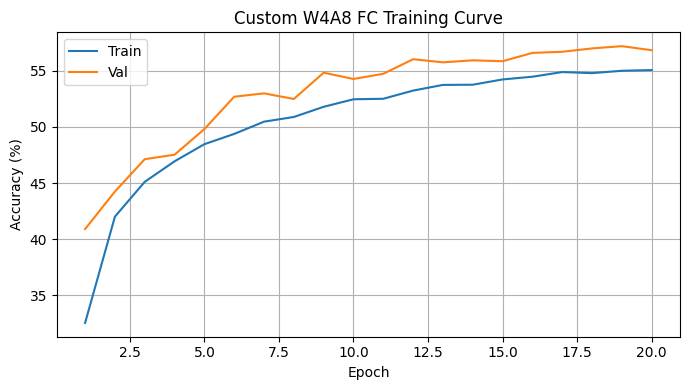

In [12]:
# Custom data loaders with augmentation for the custom model
train_transform_custom = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
])

eval_transform_custom = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
])

full_train_aug = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=train_transform_custom
)
full_train_eval = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=eval_transform_custom
)

g = torch.Generator().manual_seed(42)
perm = torch.randperm(len(full_train_aug), generator=g).tolist()
train_idx = perm[:45000]
val_idx = perm[45000:]

train_ds_custom = torch.utils.data.Subset(full_train_aug, train_idx)
val_ds_custom = torch.utils.data.Subset(full_train_eval, val_idx)

train_loader_custom = DataLoader(
    train_ds_custom, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=0, pin_memory=True
)
val_loader_custom = DataLoader(
    val_ds_custom, batch_size=256, shuffle=False,
    num_workers=0, pin_memory=True
)

def train_model_custom(model, epochs, lr, ckpt_path, train_loader_local, val_loader_local):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=5e-5)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    history = {'train_acc': [], 'val_acc': []}
    best_acc = 0.0

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader_local, optimizer, criterion)
        vl_loss, vl_acc = evaluate(model, val_loader_local, criterion)
        scheduler.step()

        history['train_acc'].append(tr_acc)
        history['val_acc'].append(vl_acc)

        print(f'Epoch {epoch:3d}/{epochs} train={tr_acc:.3f} val={vl_acc:.3f}')

        if vl_acc > best_acc:
            best_acc = vl_acc
            torch.save(model.state_dict(), ckpt_path)

    print(f'\nBest val accuracy: {best_acc:.3f} saved to {ckpt_path}')
    return history

history_custom = train_model_custom(
    model_custom,
    epochs=20,
    lr=2e-3,
    ckpt_path='finn_model_custom.pt',
    train_loader_local=train_loader_custom,
    val_loader_local=val_loader_custom
)

plot_training(history_custom, 'Custom W4A8 FC Training Curve')

In [21]:
model_custom.load_state_dict(
    torch.load('finn_model_custom.pt', map_location=DEVICE, weights_only=True)
)

model_custom.eval().cpu()
dummy = torch.randn(1, 3, 32, 32)
export_qonnx(model_custom, input_t=dummy, export_path='model_custom.onnx')
print('Exported: model_custom.onnx')

model_custom.to(DEVICE);

Exported: model_custom.onnx


QuantSmallCNNW4A8_FINN(
  (input_q): QuantIdentity(
    (input_quant): ActQuantProxyFromInjector(
      (_zero_hw_sentinel): StatelessBuffer()
      (export_handler): None
    )
    (act_quant): ActQuantProxyFromInjector(
      (_zero_hw_sentinel): StatelessBuffer()
      (fused_activation_quant_proxy): FusedActivationQuantProxy(
        (activation_impl): Identity()
        (tensor_quant): RescalingIntQuant(
          (int_quant): IntQuant(
            (float_to_int_impl): RoundSte()
            (tensor_clamp_impl): TensorClamp()
            (delay_wrapper): DelayWrapper(
              (delay_impl): _NoDelay()
            )
            (input_view_impl): Identity()
          )
          (scaling_impl): ParameterFromRuntimeStatsScaling(
            (stats_input_view_shape_impl): OverTensorView()
            (stats): _Stats(
              (stats_impl): AbsPercentile()
            )
            (abs_value): _AbsValue(
              (apply_abs): Abs()
            )
            (restrict_s

In [18]:
# Generate board test data. Set conv=True if your model is a CNN, and act_bits to its input width.
make_board_test_data('model_custom.onnx', 'test_images_custom.npy', act_bits=8, conv=True)

/home/shahlaandrew/miniforge3/envs/fpga_hw2/lib/python3.10/site-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


model_custom.onnx: scale=0.016301 clip=(-128,127) -> test_images_custom.npy (10000, 32, 32, 3)


**Explain your design choices:**

Which architecture and quantization did you choose, and why? How does your model balance **accuracy**,
**throughput**, and **latency**? Where will the throughput and latency come from in Part 2 (folding)?
What did you trade off to keep the design within the PYNQ-Z2's resources?



- we chose a small W4A8 CNN because the assignment explicitly recommends a small CNN for CIFAR-10, where convolutional spatial structure is stronger than a fully connected model.
  we kept activations at 9 bits and reduced weights to 4 bits to balance hardware cost and model quality: this is much lighter than the provided W16A8 baseline, but less extreme than the binary W2A1 setup.
  my main accuracy gain comes from using convolution plus data augmentation during training while throughput and latency will mainly be improved in part 2 through folding as the notebook describes, the main tradeoff is that we intentionally kept the CNN small enough to fix on the PYNQ-Z2 instead of chasing a wider deeper model that might fail synthesis.




In [19]:
# Summary — paste into 03_board_inference.ipynb when plotting:
print(f"sw_acc_custom = {100*max(history_custom['val_acc']):.1f}   # your model's best val accuracy")

sw_acc_custom = 50.7   # your model's best val accuracy
